# Run scVI on in vitro multiome RNA

In [1]:
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(8, 8))

Global seed set to 0
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:53: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  new_rank_zero_deprecation(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 and will be removed in v1.9. Please use `pytorch_lightning.loggers.logger.rank_zero_experiment` instead.
  return new_rank_zero_deprecation(*args, **kwargs)


In [2]:
import scanpy as sc

In [3]:
basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/scVI/'

In [4]:
adata = sc.read_h5ad(basedir + 'anndata.h5ad')

In [6]:
adata.var

,name
Xkr4,Xkr4
Gm1992,Gm1992
Gm19938,Gm19938
Gm37381,Gm37381
Rp1,Rp1
...,...
Spry3,Spry3
Tmlhe,Tmlhe
4933409K07Rik,4933409K07Rik
CAAA01147332.1,CAAA01147332.1


In [5]:
# preprocessing
sc.pp.filter_genes(adata, min_counts=3)
adata.layers["counts"] = adata.X.copy() # preserve counts
adata.raw = adata # freeze the state in `.raw`

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    subset=True,
    layer="counts",
    flavor="cell_ranger",
    batch_key="exp"
)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:478: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:478: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)


# Train model

In [11]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="exp"
)

In [12]:
model = scvi.model.SCVI(adata)

In [13]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 209/209: 100%|██████████| 209/209 [1:22:19<00:00, 23.79s/it, loss=641, v_num=1]

`Trainer.fit` stopped: `max_epochs=209` reached.


Epoch 209/209: 100%|██████████| 209/209 [1:22:19<00:00, 23.64s/it, loss=641, v_num=1]


In [14]:
model.save(basedir + 'scvi_model/')

In [6]:
model = scvi.model.SCVI.load(basedir + 'scvi_model/', adata)

INFO     File /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/scVI/scvi_model/model.pt     
         already downloaded                                                                                        


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scvi/data/_utils.py:114: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [7]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
adata.layers["scvi_normalized"] = model.get_normalized_expression(
    library_size=10e4
)

In [8]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


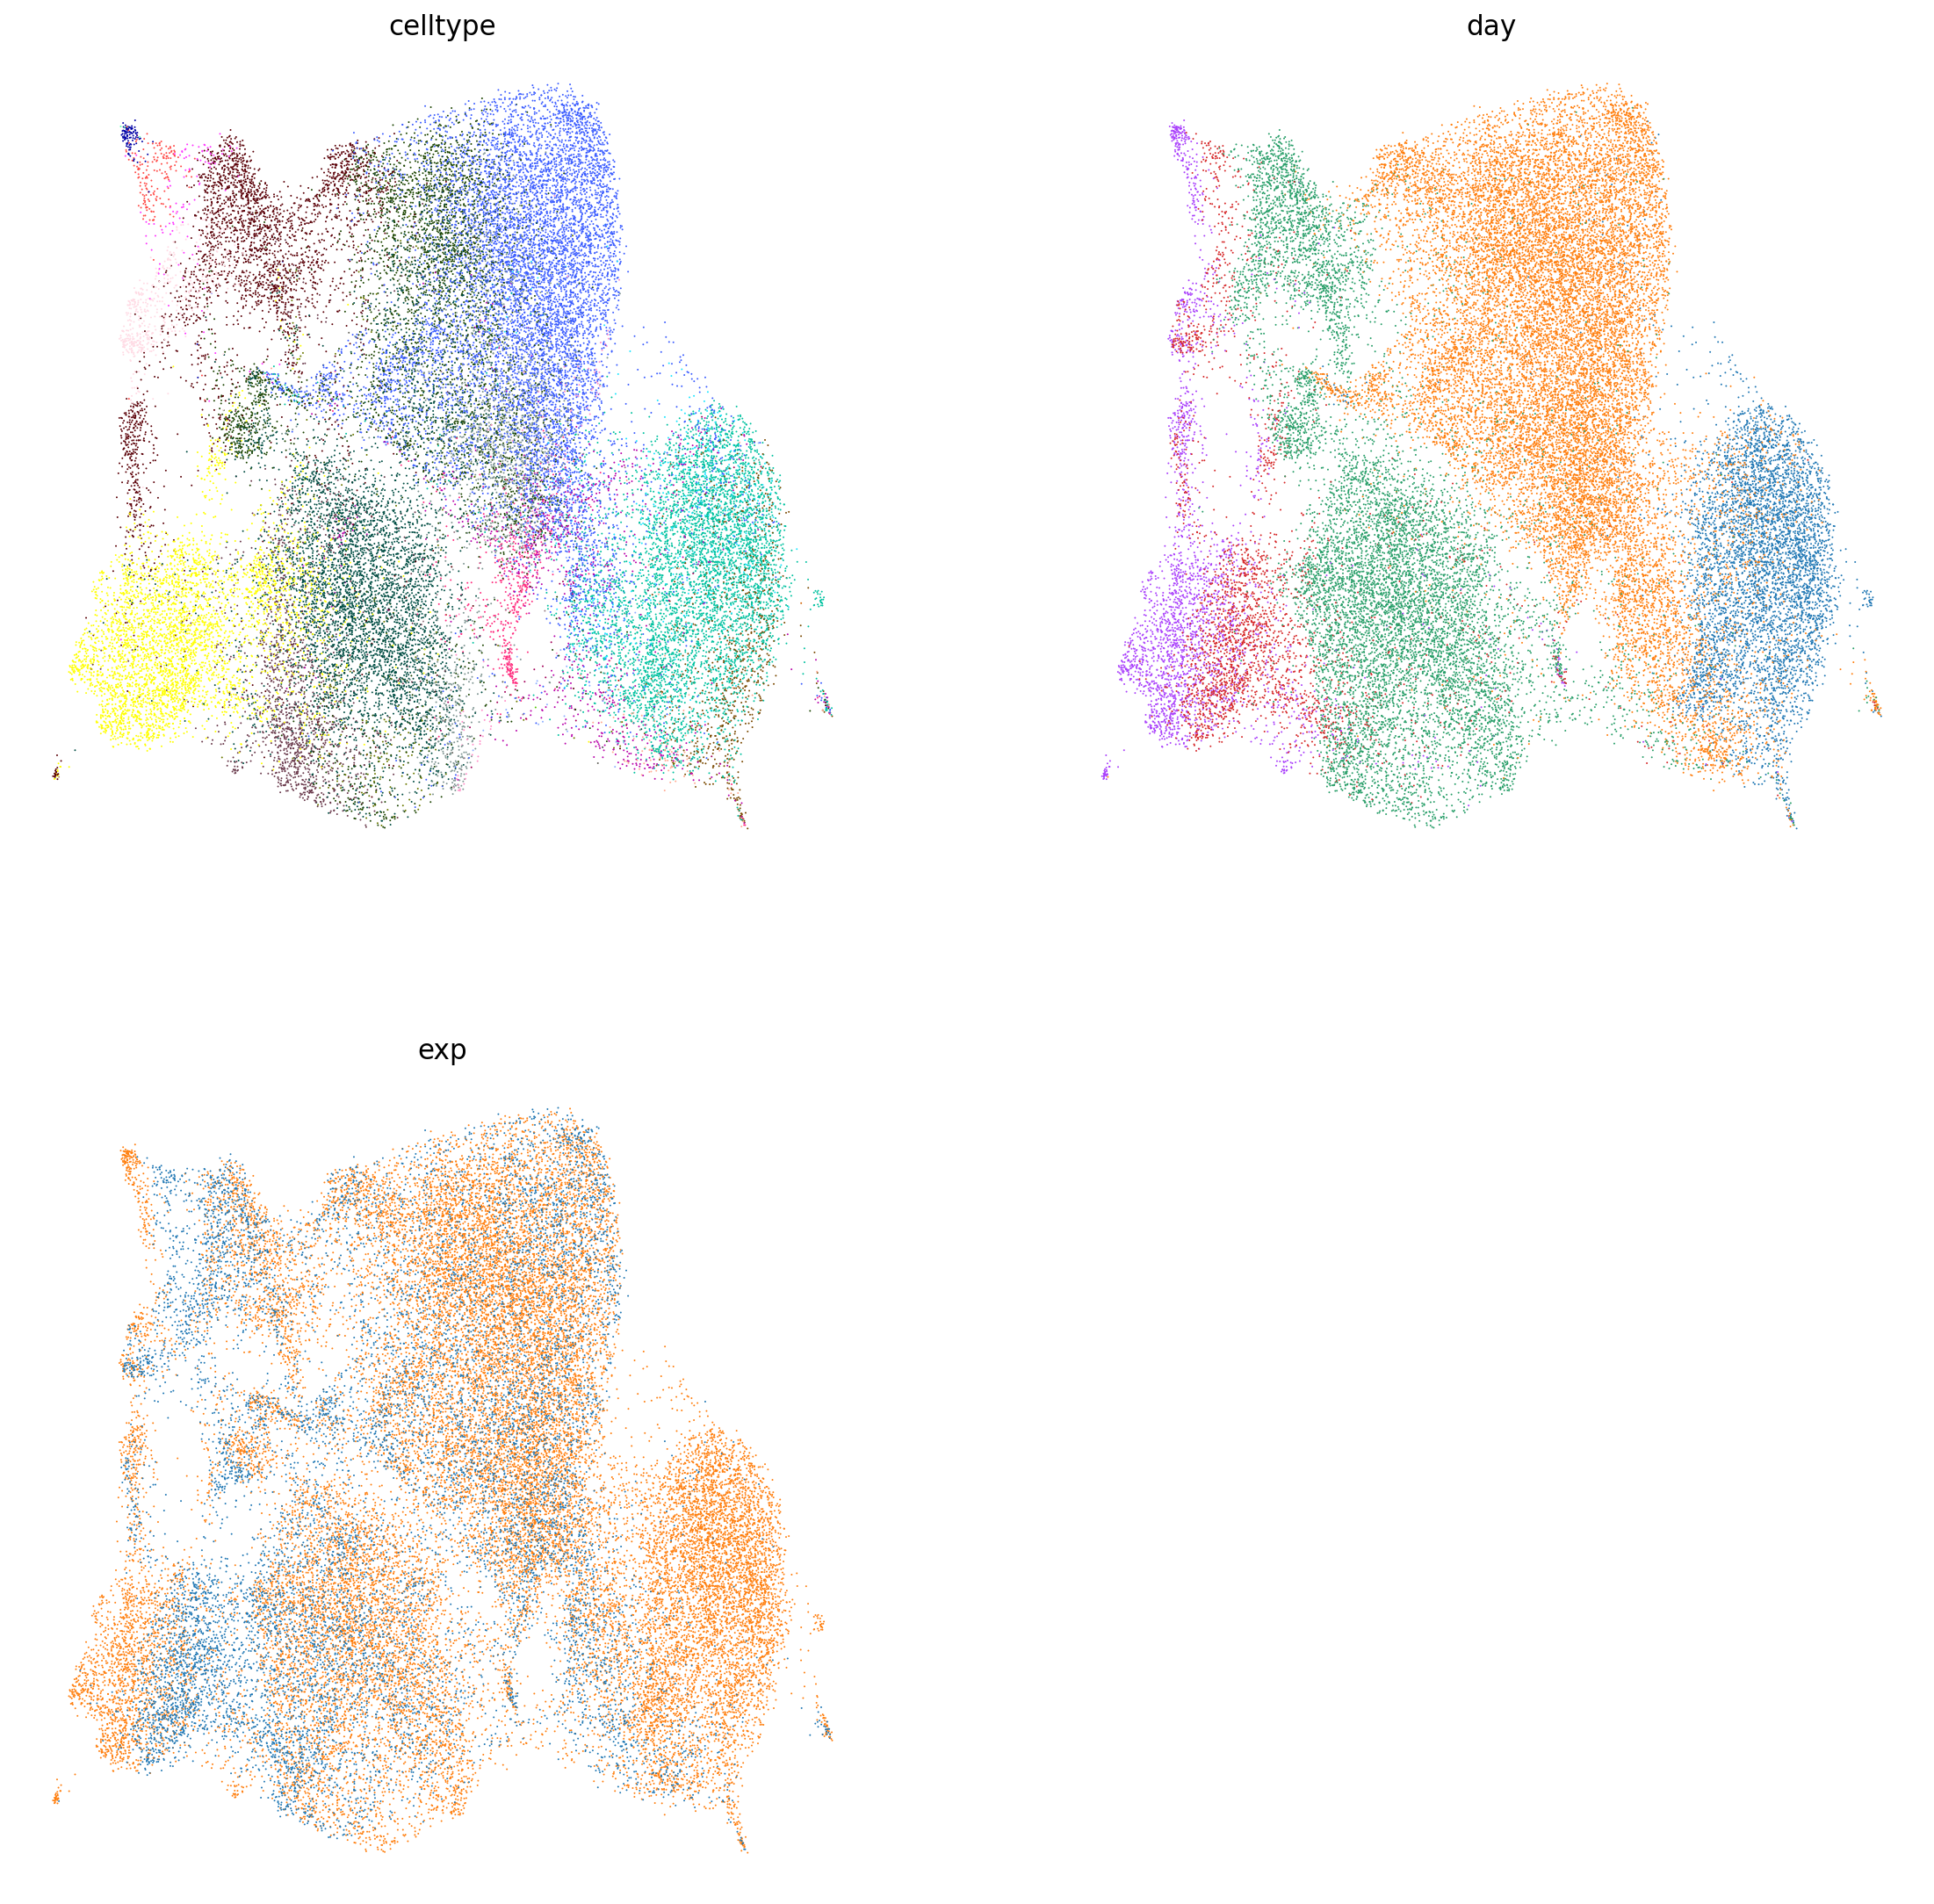

In [9]:
sc.pl.umap(
    adata,
    color=["celltype", "day", "exp"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [10]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_scVI'])

umap.to_csv(basedir + 'scVI_umap.csv')
latent.to_csv(basedir + 'scVI_latent.csv')

# Train model - day covariate

In [11]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="exp",
    categorical_covariate_keys=["day"]

)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scvi/data/_utils.py:114: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [12]:
model = scvi.model.SCVI(adata)

In [13]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 209/209: 100%|██████████| 209/209 [1:20:48<00:00, 23.50s/it, loss=636, v_num=1]

`Trainer.fit` stopped: `max_epochs=209` reached.


Epoch 209/209: 100%|██████████| 209/209 [1:20:48<00:00, 23.20s/it, loss=636, v_num=1]


In [15]:
model.save(basedir + 'scvi_model_2/')

In [16]:
model = scvi.model.SCVI.load(basedir + 'scvi_model_2/', adata)

INFO     File /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/scVI/scvi_model2/model.pt    
         already downloaded                                                                                        


/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scvi/data/_utils.py:114: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [17]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
adata.layers["scvi_normalized"] = model.get_normalized_expression(
    library_size=10e4
)

In [18]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


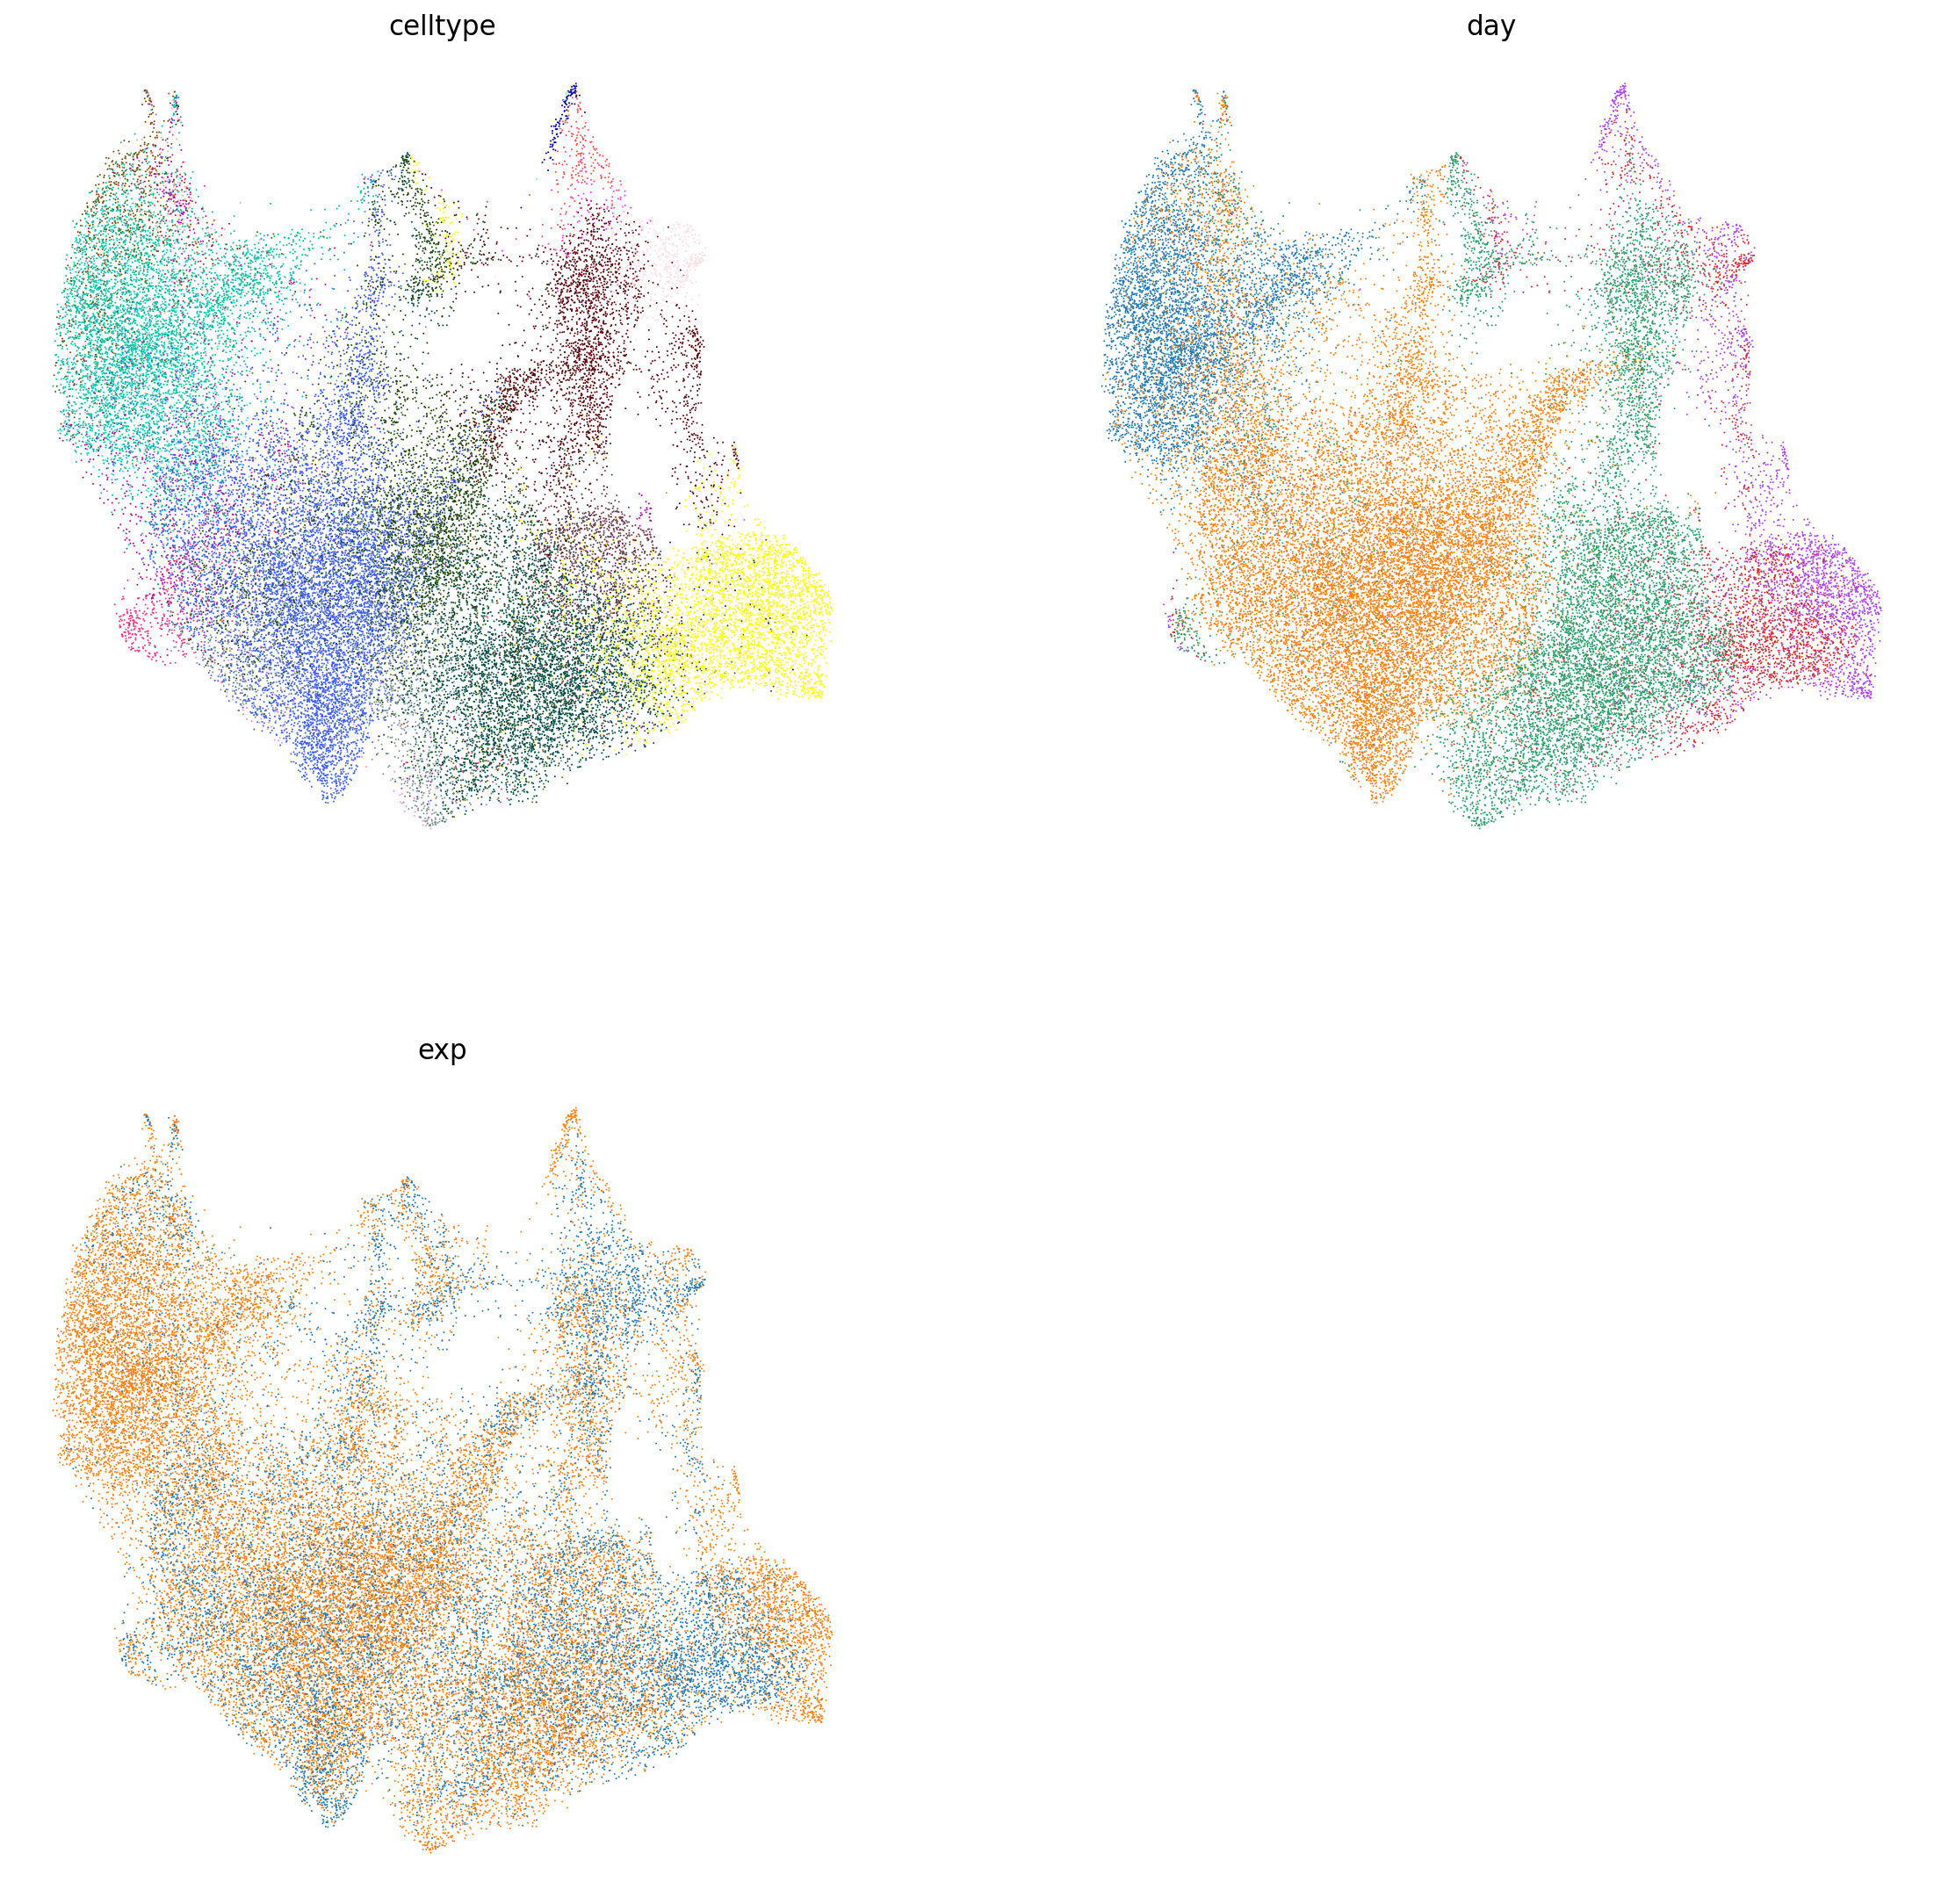

In [31]:
sc.pl.umap(
    adata,
    color=["celltype", "day", "exp"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [20]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_scVI'])

umap.to_csv(basedir + 'scVI_umap2.csv')
latent.to_csv(basedir + 'scVI_latent2.csv')

# Train model - exp covariate

In [32]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="day",
    categorical_covariate_keys=["exp"]

)

/home/bt392/miniconda3/envs/env_all/lib/python3.8/site-packages/scvi/data/_utils.py:114: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [33]:
model = scvi.model.SCVI(adata)

In [34]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 209/209: 100%|██████████| 209/209 [1:20:24<00:00, 22.97s/it, loss=641, v_num=1]

`Trainer.fit` stopped: `max_epochs=209` reached.


Epoch 209/209: 100%|██████████| 209/209 [1:20:24<00:00, 23.09s/it, loss=641, v_num=1]


In [35]:
model.save(basedir + 'scvi_model_3/')

ValueError: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/scVI/scvi_model_3/ already exists. Please provide another directory for saving.

In [ ]:
model = scvi.model.SCVI.load(basedir + 'scvi_model_3/', adata)

In [ ]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
adata.layers["scvi_normalized"] = model.get_normalized_expression(
    library_size=10e4
)

In [ ]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=35)
sc.tl.umap(adata, min_dist=0.4)

In [ ]:
sc.pl.umap(
    adata,
    color=["celltype", "day", "exp"],
    frameon=False,
    ncols=2, legend_loc='none'
)

In [ ]:
umap = pd.DataFrame(adata.obsm['X_umap'])
latent = pd.DataFrame(adata.obsm['X_scVI'])

umap.to_csv(basedir + 'scVI_umap3.csv')
latent.to_csv(basedir + 'scVI_latent3.csv')